# Structure-anchored peak-guided design — LSS (large-Stokes-shift) focus

LSS-focused copy of `guided_design_peak_structure_multiscaffold.ipynb`. Same structure-based pipeline, but
the analysis (§2b–§2d) zeroes in on the **large-Stokes-shift** targets — mBeRFP, LSS-mKate1, LSS-mKate2,
LSSmOrange, mAmetrine — and probes the chromophore-tyrosine / proton-acceptor mechanism behind their shift.
Uses the dual models retrained on the current split (DATASIG 5849fbf0); surrogate guides on
`(ex_max, em_max)`, oracle judges.

**Design tasks (scaffold → targets):**
- **DsRed** → ZsGreen, ZsYellow1, LSSmOrange, mRuby
- **avGFP** → mAmetrine, Sumire, sREACh2, Sirius
- **eqFP578** → LSS-mKate1, LSS-mKate2, mBeRFP

**Edit window (structure-based):** fetch an experimental structure (RCSB, CC0 public-domain → commercial use
OK), locate the chromophore, and edit the chromophore tripeptide **plus every residue with a heavy atom within
5 Å of the chromophore** (the color-tuning contact shell), mapped onto the dataset sequence by alignment.
Structures: DsRed **1G7K** (CRQ), avGFP **1GFL** (wt, S65-Y66-G67), eqFP578 **3M22** (TagRFP derivative,
90% id, NRQ). This recovers the canonical color residues (e.g. GFP T203/S205/H148/E222) that the old ±10
sequence window missed.

**Design settings:**
- **λ = 25** (constant) and **temperature = 10** (stochastic sampling) for every iteration, with a
  fixed **RNG seed = 42** per task (reproducible).
- All neural nets (ESM-2, surrogate, oracle) are pinned to **MPS**.
- **3 iterations** per task; each iteration edits the chromophore then the 5 Å pocket, sharing λ.
- Chromophore positions **1 = X, 2 = Tyr, 3 = Gly**: position 2 constrained to aromatics {Y,W,H,F}, position 3
  (Gly) fixed. The buried **maturation-catalytic Arg+Glu** (GFP R96/E222, DsRed R95/E215, eqFP578 R92/E215)
  are **protected** — never edited (mutating them abolishes chromophore formation).

## 0. Setup + data + dual labels

In [1]:
import csv, os, numpy as np, torch
import peak_models as pm
import prostt5_embed as pe          # ProstT5 encoder -> the (structure-aware) oracle's embedding
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception:
    HAVE_APC=False
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True
except Exception:
    HAVE_PLT=False
class _C:
    def __getattr__(self, k): return getattr(apc, k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888888","wish":"#5088c5","aster":"#7a5ea8"}.get(k,"#333333")
apc_c=_C()

CUR="../dataset_pipeline/data/peak/curated"   # curated data + dual split (new pipeline; matches sweep winners)
# all neural nets (ESM-2 surrogate + generator, ProstT5 oracle) go on this device
dev=(torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available())
     else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(CUR,"peaks_assignments.csv")))); N=len(rows)
peaks=np.load(os.path.join(CUR,"peaks.npy")).astype(np.float32); EXM=peaks[:,0]; EMM=peaks[:,1]
seqs=[None]*N; h=None
for line in open(os.path.join(CUR,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
dual=list(csv.DictReader(open(os.path.join(CUR,"dual_splits.csv"))))
Srole=np.array([d["surrogate_role"] for d in dual]); Orole=np.array([d["oracle_role"] for d in dual])
print("device",dev,"| N",N,"| surrogate roles",{b:int((Srole==b).sum()) for b in('train','val','test')})

device cuda | N 758 | surrogate roles {'train': 528, 'val': 112, 'test': 118}


## 1. Load the architectural-sweep winners and wire peak predictors

Surrogate = **ESM-2 `cnn-max-d1`** (guides generation; same pLM as the masked-LM generator) and oracle =
**ProstT5 `cnn-max-d2`** (independent structure-aware evaluator). Loaded straight from their sweep
checkpoints (scaler stats baked into each checkpoint).

In [2]:
# architectural-sweep winners: surrogate = ESM-2 cnn-max-d1 (surrogate split), oracle = ProstT5 cnn-max-d2 (oracle split)
SURR_CKPT = os.path.join("trained_models", "surrogate_sweep", "cnn-max-d1_s0.pt")
ORAC_CKPT = os.path.join("trained_models", "oracle_sweep",    "cnn-max-d2_s0.pt")
_sb, s_meta = pm.load_model(SURR_CKPT, dev); surrogate_net = pm.wrap(_sb, s_meta["mean"], s_meta["std"], dev)
_ob, o_meta = pm.load_model(ORAC_CKPT, dev); oracle_net    = pm.wrap(_ob, o_meta["mean"], o_meta["std"], dev)
print(f"surrogate: {s_meta['emb'].upper():7} {s_meta['arch']}-{s_meta['pool']}-d{s_meta['depth']} (d_in {s_meta['d_in']}) | val MAE {s_meta['val_mae']:.1f} nm")
print(f"oracle:    {o_meta['emb'].upper():7} {o_meta['arch']}-{o_meta['pool']}-d{o_meta['depth']} (d_in {o_meta['d_in']}) | val MAE {o_meta['val_mae']:.1f} nm")

g_peaks      = pm.peaks_fn(surrogate_net, dev)      # GUIDANCE: ESM-2 embed -> (B,2) nm (ex_max, em_max)
oracle_peaks = pe.prostt5_peaks_fn(oracle_net, dev) # EVALUATION: ProstT5 embed (independent pLM) -> (B,2) nm

esm_model, alphabet, bc = pm.get_esm(dev)
AA_MASK = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
for a in "ACDEFGHIKLMNPQRSTVWY": AA_MASK[alphabet.get_idx(a)] = True
AA_MASK = AA_MASK.to(dev)
SPECIAL = {alphabet.cls_idx, alphabet.eos_idx, alphabet.padding_idx, alphabet.mask_idx}

def peak_err_vec(P, target):
    """Mean absolute peak error (nm) between predicted peaks P (B,2) and a target (2,). Lower = better."""
    return 0.5*((P[:,0]-target[0]).abs() + (P[:,1]-target[1]).abs())

# --- verify every network is on the compute device ---
for _n,_net in [("ESM-2",esm_model),("surrogate",surrogate_net),("oracle",oracle_net)]:
    _d=next(_net.parameters()).device
    assert _d.type==dev.type, f"{_n} on {_d}, expected {dev.type}"
print(f"all networks on {dev} | ESM-2 {next(esm_model.parameters()).device} | surrogate {next(surrogate_net.parameters()).device} | oracle head {next(oracle_net.parameters()).device} (ProstT5 encoder loads lazily on first oracle eval)")

surrogate: ESM     cnn-max-d1 (d_in 1280) | val MAE 13.8 nm
oracle:    PROSTT5 cnn-max-d2 (d_in 1024) | val MAE 13.7 nm


all networks on cuda | ESM-2 cuda:0 | surrogate cuda:0 | oracle head cuda:0 (ProstT5 encoder loads lazily on first oracle eval)


## 2. Pseudo-perplexity (naturalness metric used during design)

In [3]:
@torch.no_grad()
def pseudo_perplexity(seq, batch_size=32):
    # mask each residue in its own row, gather the true-token logprob in one shot per batch.
    # (avoid per-element float(lp[r,p,..]) indexing -> each call forces a GPU->CPU sync on MPS)
    _,_,base=bc([("s",seq.strip().upper())]); base=base[0].to(dev)
    res=[i for i,t in enumerate(base.tolist()) if t not in SPECIAL]; tot=0.0
    for s in range(0,len(res),batch_size):
        ch=res[s:s+batch_size]
        rows=torch.arange(len(ch),device=dev); cols=torch.tensor(ch,device=dev)
        bt=base.unsqueeze(0).repeat(len(ch),1).clone(); bt[rows,cols]=alphabet.mask_idx
        lp=torch.log_softmax(esm_model(bt)["logits"],dim=-1)
        tot+=float(lp[rows,cols,base[cols]].sum())          # one gather + one sync per batch
    n=len(res); return tot, float(np.exp(-tot/n))

## 2b. LSS targets — ground truth vs. model prediction + pseudo-perplexity

Before designing, sanity-check both peak predictors on the **large-Stokes-shift (LSS)** design targets
(experimental Stokes shift ≳ 90 nm). For each LSS protein we compare the experimental (ground-truth)
`(ex_max, em_max)` against the **surrogate** (ESM-2) and **oracle** (ProstT5) predictions, and report the
sequence's ESM-2 **pseudo-perplexity** (naturalness). This shows how well the models capture these unusual
proteins — which absorb blue but emit red — before we start optimizing sequences toward them.

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

protein         SS |   exp ex/em |   surr ex/em    MAE   surr dist |   orac ex/em    MAE   orac dist |     ppl
mBeRFP         165 |   446/611   |   594/629     83.1  out (test) |   460/618     10.2 in  (train) |   17.35
LSS-mKate1     161 |   463/624   |   463/619      2.8 in  (train) |   477/625      7.8 in  (train) |   17.40
LSS-mKate2     145 |   460/605   |   458/614      5.7 in  (train) |   475/616     12.6 in  (train) |   17.43
LSSmOrange     135 |   437/572   |   428/573      5.1 in  (train) |   459/580     15.4 in  (train) |   15.47
mAmetrine      120 |   406/526   |   402/523      3.4 in  (train) |   408/528      2.3 in  (train) |   16.30
  (SS = experimental Stokes shift em-ex nm; MAE = mean |pred-exp| over ex & em nm; dist = in/out of that model's
   training distribution [surrogate & oracle have independent splits; train = in-distribution]; ppl = ESM-2 pseudo-perplexity)


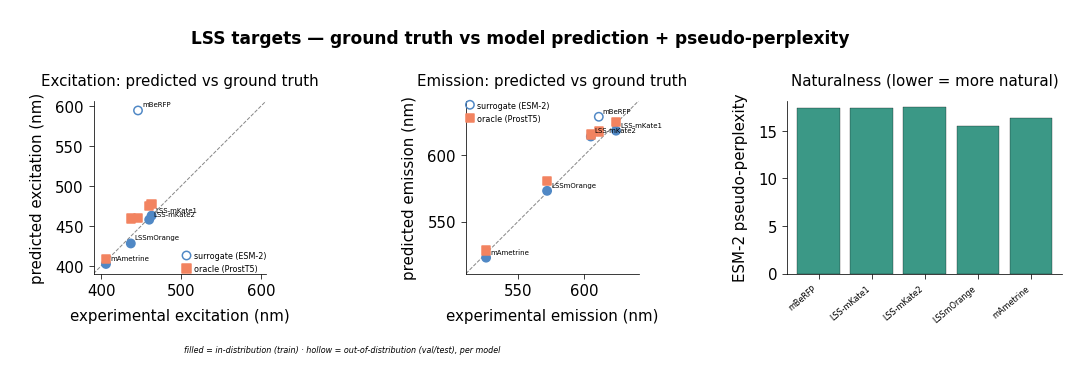

In [4]:
# LSS (large-Stokes-shift) design targets: experimental peaks vs surrogate/oracle predictions + naturalness
_name2idx = {r["name"]: i for i, r in enumerate(rows)}
LSS_NAMES = ["mBeRFP", "LSS-mKate1", "LSS-mKate2", "LSSmOrange", "mAmetrine"]   # targets with Stokes shift >= ~90 nm
LSS_NAMES = [n for n in LSS_NAMES if n in _name2idx]                            # keep only those present in dataset

_SPLIT = {int(d["index"]): (d["surrogate_role"], d["oracle_role"]) for d in dual}   # protein idx -> (surr, orac) split role
_lss = []
for nm in LSS_NAMES:
    i = _name2idx[nm]; seq = seqs[i]
    tgt = torch.tensor([float(EXM[i]), float(EMM[i])], device=dev)              # experimental (ex, em) nm
    Ps = g_peaks(seq); Po = oracle_peaks(seq)                                   # surrogate / oracle (1,2)
    _sr, _or = _SPLIT[i]                                                        # split role per model (train => in-distribution)
    _lss.append(dict(name=nm, ss=float(EMM[i] - EXM[i]), gt=(float(EXM[i]), float(EMM[i])),
                     surr=Ps[0].cpu().numpy(), orac=Po[0].cpu().numpy(),
                     surr_err=float(peak_err_vec(Ps, tgt)[0]), orac_err=float(peak_err_vec(Po, tgt)[0]),
                     ppl=float(pseudo_perplexity(seq)[1]),                      # ESM-2 pseudo-perplexity
                     surr_role=_sr, orac_role=_or))                            # in/out of each model's training distribution
_lss.sort(key=lambda d: -d["ss"])

_io = lambda r: ("in " if r == "train" else "out") + f" ({r})"                  # train split = in-distribution; val/test = OOD
print(f"{'protein':13}{'SS':>5} | {'exp ex/em':>11} | {'surr ex/em':>12}{'MAE':>7}{'surr dist':>12} | {'orac ex/em':>12}{'MAE':>7}{'orac dist':>12} | {'ppl':>7}")
for d in _lss:
    print(f"{d['name']:13}{d['ss']:>5.0f} | {d['gt'][0]:>5.0f}/{d['gt'][1]:<5.0f} | "
          f"{d['surr'][0]:>5.0f}/{d['surr'][1]:<5.0f}{d['surr_err']:>7.1f}{_io(d['surr_role']):>12} | "
          f"{d['orac'][0]:>5.0f}/{d['orac'][1]:<5.0f}{d['orac_err']:>7.1f}{_io(d['orac_role']):>12} | {d['ppl']:>7.2f}")
print("  (SS = experimental Stokes shift em-ex nm; MAE = mean |pred-exp| over ex & em nm; dist = in/out of that model's")
print("   training distribution [surrogate & oracle have independent splits; train = in-distribution]; ppl = ESM-2 pseudo-perplexity)")

if HAVE_PLT:
    fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.6))
    for k, lab in [(0, "excitation"), (1, "emission")]:
        vals = [v for d in _lss for v in (d["gt"][k], d["surr"][k], d["orac"][k])]
        lo, hi = min(vals) - 12, max(vals) + 12
        ax[k].plot([lo, hi], [lo, hi], "--", color="#888", lw=1, zorder=0)                       # y = x (perfect)
        _sf = [apc_c.aegean if d["surr_role"] == "train" else "none" for d in _lss]   # filled = in-distribution, hollow = OOD
        _of = [apc_c.amber  if d["orac_role"] == "train" else "none" for d in _lss]
        ax[k].scatter([d["gt"][k] for d in _lss], [d["surr"][k] for d in _lss], s=70, facecolors=_sf, edgecolors=apc_c.aegean, linewidths=1.5, label="surrogate (ESM-2)")
        ax[k].scatter([d["gt"][k] for d in _lss], [d["orac"][k] for d in _lss], s=70, marker="s", facecolors=_of, edgecolors=apc_c.amber, linewidths=1.5, label="oracle (ProstT5)")
        for d in _lss: ax[k].annotate(d["name"], (d["gt"][k], d["surr"][k]), fontsize=7, xytext=(4, 4), textcoords="offset points")
        ax[k].set_xlim(lo, hi); ax[k].set_ylim(lo, hi); ax[k].set_aspect("equal")
        ax[k].set_xlabel(f"experimental {lab} (nm)"); ax[k].set_ylabel(f"predicted {lab} (nm)")
        ax[k].set_title(f"{lab.capitalize()}: predicted vs ground truth"); ax[k].legend(fontsize=8)
    x = np.arange(len(_lss))
    ax[2].bar(x, [d["ppl"] for d in _lss], color=apc_c.seaweed, edgecolor="black", linewidth=0.3)
    ax[2].set_xticks(x); ax[2].set_xticklabels([d["name"] for d in _lss], rotation=40, ha="right", fontsize=8)
    ax[2].set_ylabel("ESM-2 pseudo-perplexity"); ax[2].set_title("Naturalness (lower = more natural)")
    fig.suptitle("LSS targets — ground truth vs model prediction + pseudo-perplexity", fontweight="bold")
    fig.text(0.34, 0.005, "filled = in-distribution (train) · hollow = out-of-distribution (val/test), per model", ha="center", fontsize=8, style="italic")
    fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

## 2c. Why the LSS designs fall short — window-recovery test

§2b shows the surrogate predicts the *natural* LSS proteins well (in-distribution), yet guided designs plateau
~50–60 nm from target. To separate **surrogate quality** from **design-window capacity**, apply to each
scaffold *only the natural mutations that fall inside the editable window* (chromophore + 5 Å pocket) —
the "window-mut" — and ask how much of the spectral shift that recovers vs. the full natural protein:

- If **window-mut already reaches target** → the window suffices and any residual is a search problem.
- If **window-mut stays near the scaffold** while the **full natural protein** is predicted on-target → the
  phenotype lives in the ~80 % of mutations *outside* the window, so the **window is the bottleneck**.

The window is recomputed here self-contained (same chromophore + 5 Å definition as §4).

pair                      tgt exp | surrogate MAE (nm):  scaf -> window-mut -> full-nat | in-win/total subs
eqFP578->mBeRFP          446/611 |       66 ->         65 ->      83   | 4/26
eqFP578->LSS-mKate1      463/624 |       64 ->         53 ->       3   | 5/28
eqFP578->LSS-mKate2      460/605 |       56 ->         46 ->       6   | 5/28
DsRed->LSSmOrange        437/572 |       71 ->         54 ->       5   | 6/37
avGFP->mAmetrine         406/526 |       28 ->         14 ->       3   | 5/25
  window-mut = scaffold + ONLY the natural mutations inside the chromophore+5A window; full-nat = the real target protein


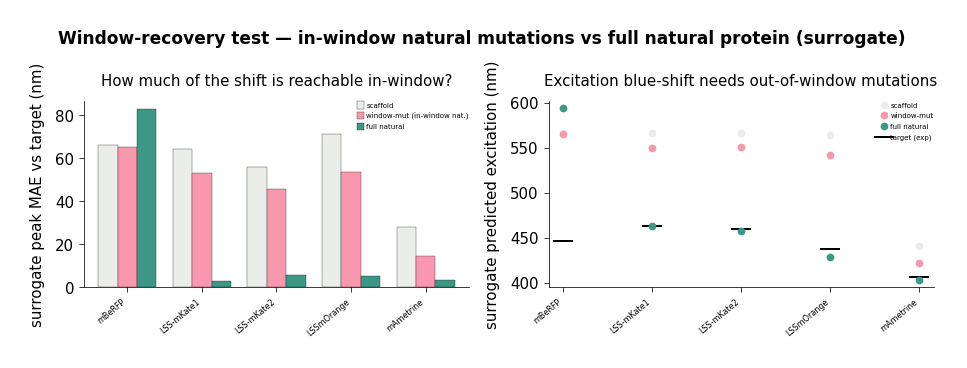

In [5]:
# Window-recovery test: apply ONLY the in-window natural mutations to each scaffold; surrogate (guidance model)
# judges how much of the LSS shift that recovers vs the full natural protein. Self-contained window (same def as §4).
import numpy as np, torch
import biotite.sequence as _bs, biotite.sequence.align as _ba
import biotite.structure.io.pdbx as _pdbx2, biotite.database.rcsb as _rcsb2

_MATW = _ba.SubstitutionMatrix.std_protein_matrix(); _CH2W = set("YWHF")
_C3W = "ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL".split()
_T3W = {c: o for c, o in zip(_C3W, "A R N D C Q E G H I L K M F P S T W Y V".split())}
_STRUCTW = {"DsRed": ("1G7K", ("CRQ",)), "avGFP": ("1GFL", ()), "eqFP578": ("3M22", ("NRQ",))}
_CATW = {"DsRed": (95, 215), "avGFP": (96, 222), "eqFP578": (92, 215)}
LSS_SCAF = {"mBeRFP": "eqFP578", "LSS-mKate1": "eqFP578", "LSS-mKate2": "eqFP578",
            "LSSmOrange": "DsRed", "mAmetrine": "avGFP"}                    # each LSS target -> its design scaffold

def _cidxW(seq, lo=50, hi=85):
    yg = [i for i in range(len(seq) - 2) if seq[i + 1] == "Y" and seq[i + 2] == "G" and lo <= i <= hi]
    an = [i for i in range(len(seq) - 2) if seq[i + 1] in _CH2W and seq[i + 2] == "G" and lo <= i <= hi]
    return min((yg or an), key=lambda i: abs(i - 65))

def _windowW(name, seq):                                                   # 0-based editable: chromo pos1,2 + 5A pocket
    pdb, het = _STRUCTW[name]
    arr = _pdbx2.get_structure(_pdbx2.CIFFile.read(_rcsb2.fetch(pdb, "pdbx", "structures")), model=1)
    a = arr[(arr.chain_id == sorted(set(arr.chain_id))[0]) & (arr.element != "H")]
    resids, letters, seen = [], [], set()
    for rid, rn in zip(a.res_id.tolist(), a.res_name.tolist()):
        if rid in seen: continue
        seen.add(rid)
        if rn in _T3W: resids.append(int(rid)); letters.append(_T3W[rn])
    aln = _ba.align_optimal(_bs.ProteinSequence("".join(letters)), _bs.ProteinSequence(seq), _MATW, gap_penalty=(-10, -1))[0]
    tr = aln.trace; s2d = {resids[tr[r, 0]]: int(tr[r, 1]) for r in range(tr.shape[0]) if tr[r, 0] >= 0 and tr[r, 1] >= 0}
    d2s = {v: k for k, v in s2d.items()}; c1 = _cidxW(seq); tri = {c1, c1 + 1, c1 + 2}
    cmask = np.isin(a.res_name, het) if het else np.isin(a.res_id, [d2s[p] for p in tri if p in d2s])
    ccoord = a[cmask].coord; prot = a[(~cmask) & np.isin(a.res_name, _C3W)]; catal = {p - 1 for p in _CATW[name]}
    pk = []
    for rid in dict.fromkeys(prot.res_id.tolist()):
        rc = prot[prot.res_id == rid].coord
        if np.sqrt(((rc[:, None, :] - ccoord[None, :, :]) ** 2).sum(-1)).min() <= 5.0 and rid in s2d:
            dp = s2d[rid]
            if dp not in tri and dp not in catal: pk.append(dp)
    return {c1, c1 + 1} | set(pk)

def _subsW(ss, ts):                                                        # substitutions (0-based scaf pos, target aa)
    aln = _ba.align_optimal(_bs.ProteinSequence(ss), _bs.ProteinSequence(ts), _MATW, gap_penalty=(-10, -1))[0]; tr = aln.trace
    return [(tr[r, 0], ts[tr[r, 1]]) for r in range(tr.shape[0]) if tr[r, 0] >= 0 and tr[r, 1] >= 0 and ss[tr[r, 0]] != ts[tr[r, 1]]]

_rec = []
for nm in [n for n in LSS_NAMES if n in LSS_SCAF]:
    scaf = LSS_SCAF[nm]; si = _name2idx[scaf]; ti = _name2idx[nm]
    ss = seqs[si]; ts = seqs[ti]; texp = (float(EXM[ti]), float(EMM[ti]))
    win = _windowW(scaf, ss); subs = _subsW(ss, ts); inwin = [(p, aa) for p, aa in subs if p in win]
    mut = list(ss)
    for p, aa in inwin: mut[p] = aa
    mut = "".join(mut)                                                     # scaffold + ONLY the in-window natural mutations
    S = {k: g_peaks(s)[0].cpu().numpy() for k, s in [("scaf", ss), ("winmut", mut), ("full", ts)]}   # surrogate (guides)
    O = {k: oracle_peaks(s)[0].cpu().numpy() for k, s in [("scaf", ss), ("winmut", mut), ("full", ts)]}
    er = lambda p, t=texp: 0.5 * (abs(p[0] - t[0]) + abs(p[1] - t[1]))
    _rec.append(dict(name=nm, scaf=scaf, texp=texp, ninwin=len(inwin), ntot=len(subs),
                     muts=[f"{ss[p]}{p+1}{aa}" for p, aa in inwin], S=S, O=O, er=er))

print(f"{'pair':24}{'tgt exp':>9} | surrogate MAE (nm):  scaf -> window-mut -> full-nat | in-win/total subs")
for d in _rec:
    er = d["er"]
    print(f"{d['scaf']+'->'+d['name']:24}{d['texp'][0]:>4.0f}/{d['texp'][1]:<4.0f}| "
          f"{er(d['S']['scaf']):>8.0f} -> {er(d['S']['winmut']):>10.0f} -> {er(d['S']['full']):>7.0f}   | {d['ninwin']}/{d['ntot']}")
print("  window-mut = scaffold + ONLY the natural mutations inside the chromophore+5A window; full-nat = the real target protein")

if HAVE_PLT:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
    names = [d["name"] for d in _rec]; x = np.arange(len(names)); w = 0.26
    cols = {"scaf": apc_c.gray, "winmut": apc_c.rose, "full": apc_c.seaweed}
    for j, (k, lab) in enumerate([("scaf", "scaffold"), ("winmut", "window-mut (in-window nat.)"), ("full", "full natural")]):
        ax[0].bar(x + (j - 1) * w, [d["er"](d["S"][k]) for d in _rec], w, label=lab, color=cols[k], edgecolor="black", linewidth=0.3)
    ax[0].set_xticks(x); ax[0].set_xticklabels(names, rotation=40, ha="right", fontsize=8)
    ax[0].set_ylabel("surrogate peak MAE vs target (nm)"); ax[0].set_title("How much of the shift is reachable in-window?"); ax[0].legend(fontsize=7)
    for k, lab in [("scaf", "scaffold"), ("winmut", "window-mut"), ("full", "full natural")]:
        ax[1].scatter(x, [d["S"][k][0] for d in _rec], s=60, color=cols[k], label=lab, zorder=3)
    ax[1].scatter(x, [d["texp"][0] for d in _rec], marker="_", s=420, color="black", linewidths=2, label="target (exp)", zorder=2)
    ax[1].set_xticks(x); ax[1].set_xticklabels(names, rotation=40, ha="right", fontsize=8)
    ax[1].set_ylabel("surrogate predicted excitation (nm)"); ax[1].set_title("Excitation blue-shift needs out-of-window mutations"); ax[1].legend(fontsize=7)
    fig.suptitle("Window-recovery test — in-window natural mutations vs full natural protein (surrogate)", fontweight="bold")
    fig.tight_layout(); plt.show()

## 2d. Chromophore-Tyr / proton-acceptor knockout probe

The large Stokes shift is a **chromophore-mechanism** phenomenon: the neutral (protonated) chromophore absorbs
blue, then an **excited-state proton transfer (ESPT)** to an internal **carboxylate acceptor** yields the
red-emitting anion. Two residues are mechanistically decisive: the **chromophore tyrosine** (its phenol –OH is
the proton donor) and the **proton acceptor** (an Asp/Glu introduced next to the chromophore).

Here we start from each *natural* LSS protein and knock out these residues, then ask whether the surrogate
(ESM-2) and oracle (ProstT5) predict the **collapse of the large Stokes shift** (excitation should red-shift
back toward a normal FP):

- **Tyr KO** — chromophore `Y → F` (removes the phenol –OH, abolishing ESPT / anion formation).
- **acceptor KO** — carboxylate `D → N` or `E → Q` (isosteric, removes the proton-accepting negative charge).
- **both**.

Acceptor positions are taken from the scaffold→LSS diff + LSS literature (LSS-mKate1 Glu160, LSS-mKate2 Asp160,
mBeRFP Asp158, LSSmOrange Asp161, mAmetrine Glu222 — the GFP-type catalytic/ESPT glutamate), mapped into each
protein's own numbering by alignment. If the models causally understand the mechanism, these single-residue
knockouts should move the predicted excitation; if they are insensitive, it reinforces that the peak predictors
model these proteins largely by sequence similarity rather than by ESPT mechanism.

Knockout probe on natural LSS proteins — predicted (ex/em) nm; Δ = shift vs natural LSS (surrogate)

### mBeRFP | exp 446/611 nm | chromo Tyr@68 | acceptor D162
    variant                     surrogate ex/em     Δex/Δem |    oracle ex/em     Δex/Δem
    natural LSS                   594/629          +0/+0 |    460/618          +0/+0
    Tyr KO (Y68F)                 575/606        -19/-23 |    446/602        -14/-16
    acceptor KO (D162N)           600/636          +6/+7 |    541/644        +82/+26
    both KO                       585/617        -10/-13 |    502/626         +42/+9

### LSS-mKate1 | exp 463/624 nm | chromo Tyr@64 | acceptor E160
    variant                     surrogate ex/em     Δex/Δem |    oracle ex/em     Δex/Δem
    natural LSS                   463/619          +0/+0 |    477/625          +0/+0
    Tyr KO (Y64F)                 442/591        -21/-28 |    467/618         -10/-7
    acceptor KO (E160Q)           488/622         +25/+3 |    499/631         +22/+6

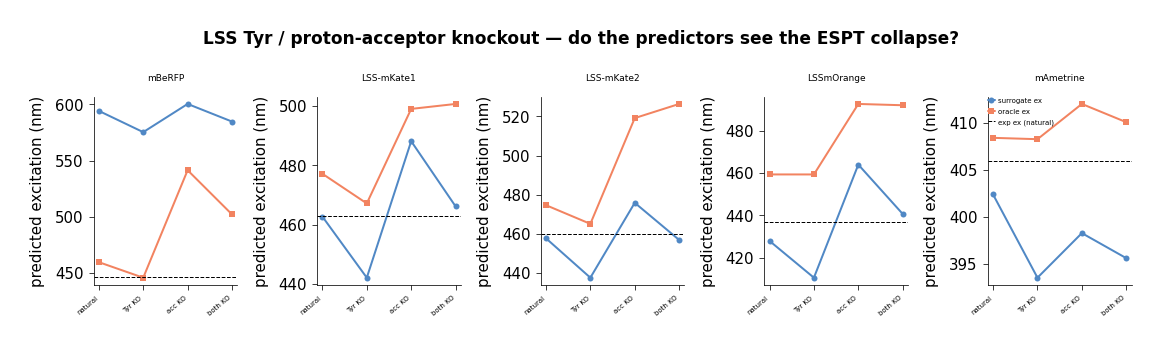

In [6]:
# Chromophore-Tyr / proton-acceptor knockout probe on the natural LSS proteins.
# Knock out the chromophore tyrosine (Y->F), the proton-acceptor carboxylate (D->N / E->Q), or both, and check
# whether surrogate (ESM-2) & oracle (ProstT5) predict the resulting shift in the excitation/emission spectrum.
import numpy as np, torch
import biotite.sequence as _bsL, biotite.sequence.align as _baL
_MATL = _baL.SubstitutionMatrix.std_protein_matrix(); _CH2L = set("YWHF")

def _cidxL(seq, lo=50, hi=85):                                          # chromophore pos-1 index (X of X-[YWHF]-G)
    yg = [i for i in range(len(seq) - 2) if seq[i + 1] == "Y" and seq[i + 2] == "G" and lo <= i <= hi]
    an = [i for i in range(len(seq) - 2) if seq[i + 1] in _CH2L and seq[i + 2] == "G" and lo <= i <= hi]
    return min((yg or an), key=lambda i: abs(i - 65))

def _map_pos(ss, ts, p_scaf):                                          # scaffold 0-based pos -> target 0-based pos
    aln = _baL.align_optimal(_bsL.ProteinSequence(ss), _bsL.ProteinSequence(ts), _MATL, gap_penalty=(-10, -1))[0]; tr = aln.trace
    for r in range(tr.shape[0]):
        if tr[r, 0] == p_scaf and tr[r, 1] >= 0: return int(tr[r, 1])
    return None

# per LSS target: (scaffold, proton-acceptor position in SCAFFOLD 1-based numbering)
LSS_PROBE = {"mBeRFP": ("eqFP578", 158), "LSS-mKate1": ("eqFP578", 160), "LSS-mKate2": ("eqFP578", 160),
             "LSSmOrange": ("DsRed", 161), "mAmetrine": ("avGFP", 222)}
_KO = {"D": "N", "E": "Q"}                                             # carboxylate -> isosteric amide (acceptor KO)
def _apply(seq, muts): s = list(seq); [s.__setitem__(p, aa) for p, aa in muts]; return "".join(s)

rows_probe = []
for nm, (scaf, accs1) in LSS_PROBE.items():
    if nm not in _name2idx: continue
    ti = _name2idx[nm]; ts = seqs[ti]; ss = seqs[_name2idx[scaf]]; texp = (float(EXM[ti]), float(EMM[ti]))
    cY = _cidxL(ts) + 1                                                # chromophore tyrosine (pos-2), 0-based
    accp = _map_pos(ss, ts, accs1 - 1)                                 # proton acceptor in target numbering, 0-based
    tyr_ok = ts[cY] == "Y"; acc_res = ts[accp] if accp is not None else "?"; acc_ok = acc_res in _KO
    tyr_mut = [(cY, "F")] if tyr_ok else []
    acc_mut = [(accp, _KO[acc_res])] if acc_ok else []
    acc_lbl = f"acceptor KO ({acc_res}{accp + 1}{_KO[acc_res]})" if acc_ok else "acceptor KO (n/a)"
    variants = {"natural LSS": ts, f"Tyr KO (Y{cY + 1}F)": _apply(ts, tyr_mut),
                acc_lbl: _apply(ts, acc_mut), "both KO": _apply(ts, tyr_mut + acc_mut)}
    preds = {k: (g_peaks(v)[0].cpu().numpy(), oracle_peaks(v)[0].cpu().numpy()) for k, v in variants.items()}
    rows_probe.append(dict(name=nm, texp=texp, cY=cY + 1, accp=(accp + 1 if accp is not None else None),
                           acc_res=acc_res, keys=list(variants.keys()), preds=preds, tyr_ok=tyr_ok, acc_ok=acc_ok))

print("Knockout probe on natural LSS proteins — predicted (ex/em) nm; Δ = shift vs natural LSS (surrogate)")
for d in rows_probe:
    ns, no = d["preds"]["natural LSS"]
    print(f"\n### {d['name']} | exp {d['texp'][0]:.0f}/{d['texp'][1]:.0f} nm | chromo Tyr@{d['cY']} | acceptor {d['acc_res']}{d['accp']}"
          + ("" if d["acc_ok"] else "  [acceptor not D/E at mapped pos — KO skipped]"))
    print(f"    {'variant':26}{'surrogate ex/em':>17}{'Δex/Δem':>12} | {'oracle ex/em':>15}{'Δex/Δem':>12}")
    for k in d["keys"]:
        s, o = d["preds"][k]
        print(f"    {k:26}{s[0]:>7.0f}/{s[1]:<6.0f}{f'{s[0]-ns[0]:+.0f}/{s[1]-ns[1]:+.0f}':>12} | "
              f"{o[0]:>6.0f}/{o[1]:<6.0f}{f'{o[0]-no[0]:+.0f}/{o[1]-no[1]:+.0f}':>12}")
print("\n  Expected if ESPT is captured: acceptor/Tyr KO should RED-shift excitation (Δex > 0), collapsing the large Stokes shift.")

if HAVE_PLT:
    n = len(rows_probe); fig, ax = plt.subplots(1, n, figsize=(3.15 * n, 4.3))
    if n == 1: ax = [ax]
    short = ["natural", "Tyr KO", "acc KO", "both KO"]
    for a, d in zip(ax, rows_probe):
        xs = np.arange(4)
        se = [d["preds"][k][0][0] for k in d["keys"]]; oe = [d["preds"][k][1][0] for k in d["keys"]]
        a.plot(xs, se, "o-", color=apc_c.aegean, label="surrogate ex"); a.plot(xs, oe, "s-", color=apc_c.amber, label="oracle ex")
        a.axhline(d["texp"][0], ls="--", color="black", lw=1, label="exp ex (natural)")
        a.set_xticks(xs); a.set_xticklabels(short, rotation=40, ha="right", fontsize=7)
        a.set_title(d["name"], fontsize=9); a.set_ylabel("predicted excitation (nm)")
    ax[-1].legend(fontsize=7)
    fig.suptitle("LSS Tyr / proton-acceptor knockout — do the predictors see the ESPT collapse?", fontweight="bold")
    fig.tight_layout(); plt.show()

## 3. Guided refinement (surrogate guides on peaks, oracle evaluates)

In [7]:
def to_tokens(seq):
    _, _, t = bc([("q", seq.strip().upper())]); return t.to(dev)
def tokens_to_seq(t1d):
    return "".join(alphabet.get_tok(t) for t in t1d.tolist() if t not in SPECIAL)

@torch.no_grad()
def guided_refine(seq, target, n_sweeps=1, k=6, lam_ex=25.0, lam_em=25.0, temperature=0.0, editable=None, eval_fn=None,
                  pos_allowed=None, verbose=True):
    """target: torch tensor (2,) = (ex_max, em_max) nm. Per-candidate score =
        z(log p_ESM) - lam_ex * z(|pred_ex - target_ex|) - lam_em * z(|pred_em - target_em|)
    i.e. naturalness plus SEPARATE excitation- and emission-MAE guidance terms. Each term is z-scored over
    the k candidates, so lam_ex / lam_em share the log-prob term's scale (set them equal to recover a
    balanced ex+em objective; raise one to prioritise that peak).
    pos_allowed: optional {residue_0based_index: bool vocab-mask} restricting candidate AAs at that position
    (e.g. chromophore position 2 -> aromatic only). Positions absent from the dict use the full AA_MASK."""
    toks = to_tokens(seq)
    res = [i for i, t in enumerate(toks[0].tolist()) if t not in SPECIAL]
    if editable is not None: res = [res[j] for j in editable]
    trace = []
    for sweep in range(n_sweeps):
        for pos in res:
            mask_here = AA_MASK
            if pos_allowed is not None and (pos - 1) in pos_allowed:   # pos is a token index; residue = pos-1
                mask_here = pos_allowed[pos - 1]
            toks[0, pos] = alphabet.mask_idx
            lg = esm_model(toks)["logits"][0, pos].masked_fill(~mask_here, float("-inf"))
            logp = torch.log_softmax(lg, -1)
            k_eff = min(k, int(mask_here.sum().item()))                # cap k to #allowed AAs (avoids -inf picks)
            topv, topi = torch.topk(logp, k_eff)
            cand = []
            for idx in topi.tolist(): toks[0, pos] = idx; cand.append(tokens_to_seq(toks[0]))
            P = g_peaks(cand)                                          # surrogate (ESM) predicted (ex, em) nm, (k,2)
            ex_err = (P[:, 0] - target[0]).abs()                       # |pred_ex - target_ex| per candidate
            em_err = (P[:, 1] - target[1]).abs()                       # |pred_em - target_em| per candidate
            zc = lambda t: (t - t.mean()) / (t.std() + 1e-6)           # z-score over the k candidates
            scores = zc(topv) - lam_ex * zc(ex_err) - lam_em * zc(em_err)  # naturalness - λ1·ex MAE - λ2·em MAE
            ch = (torch.multinomial(torch.softmax(scores / temperature, -1), 1).item() if temperature > 0 else int(torch.argmax(scores)))
            toks[0, pos] = int(topi[ch].item())
        cur = tokens_to_seq(toks[0])
        ev = (eval_fn(cur) if eval_fn is not None else g_peaks(cur))   # oracle evaluation (B,2)
        err_ev = float(peak_err_vec(ev, target)[0]); trace.append(err_ev)
        if verbose: print(f"  sweep {sweep}: oracle peak err {err_ev:.1f} nm")
    return tokens_to_seq(toks[0]), trace


## 4. Structure-based edit window, phase plan, and task selection

For each scaffold we fetch an experimental structure and take the chromophore tripeptide plus its **5 Å
heavy-atom contact shell** as the editable set (`_struct_pocket`), mapped to dataset numbering by alignment.
The plan is a single phase of **3 iterations**, each editing the **chromophore (positions 1, 2) then the 5 Å
pocket** at **constant λ = 25** and **temperature 10**. `POS2_AROMATIC` bounds position-2 to aromatics; Gly
(pos 3) and the catalytic Arg+Glu are excluded so they stay fixed. `RUN_GENERATION=True` generates + saves
all tasks to `OUTDIR` (resumable).

In [8]:
import glob
import numpy as np
import biotite.sequence as _bseq, biotite.sequence.align as _balign
import biotite.structure.io.pdbx as _pdbx
import biotite.database.rcsb as _rcsb
_MAT = _balign.SubstitutionMatrix.std_protein_matrix()
def seq_identity(a, b):
    aln = _balign.align_optimal(_bseq.ProteinSequence(a), _bseq.ProteinSequence(b), _MAT, gap_penalty=(-10, -1))[0]
    return float(_balign.get_sequence_identity(aln))
def sanitize(s): return "".join(ch if (ch.isalnum() or ch in "-_.") else "_" for ch in s)

# ---- chromophore location -----------------------------------------------------------------
CHROMO_AA2 = set("YWHF")   # position-2 ring: Tyr (green/red), Trp (cyan), His (blue), Phe
def chromophore_index(seq, lo=50, hi=85):
    """0-based index of chromophore position 1 (the X before the pos2-[Gly])."""
    yg   = [i for i in range(len(seq)-2) if seq[i+1] == "Y"          and seq[i+2] == "G" and lo <= i <= hi]
    any_ = [i for i in range(len(seq)-2) if seq[i+1] in CHROMO_AA2 and seq[i+2] == "G" and lo <= i <= hi]
    cand = yg or any_
    if not cand: raise ValueError("no X-[YWHF]-G chromophore motif near canonical position")
    return min(cand, key=lambda i: abs(i-65))

# ---- STRUCTURE-BASED edit window (chromophore + 5 A contact shell) -------------------------
# Replaces the old sequence ±10 window. For each scaffold we fetch an experimental structure
# (RCSB, CC0 / public-domain -> commercial use OK), locate the chromophore, and take every residue
# with a heavy atom within CUTOFF of any chromophore heavy atom, mapped onto the dataset sequence
# numbering by pairwise alignment. The chromophore tripeptide and the buried maturation-catalytic
# Arg+Glu are EXCLUDED (never edited).
_CANON3 = "ALA ARG ASN ASP CYS GLN GLU GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL".split()
_T3 = {c: o for c, o in zip(_CANON3, "A R N D C Q E G H I L K M F P S T W Y V".split())}
STRUCTDIR = "structures"; os.makedirs(STRUCTDIR, exist_ok=True)
CUTOFF = 5.0                                    # heavy-atom min distance (A) defining the pocket
# scaffold -> (pdb_id, chromophore hetero-residue codes; () -> derive chromophore from the tripeptide)
STRUCT = {"DsRed": ("1G7K", ("CRQ",)),          # 96% id, mature CRQ chromophore
          "avGFP": ("1GFL", ()),                # wt GFP, 99% id; chromophore modeled as plain S65-Y66-G67
          "eqFP578": ("3M22", ("NRQ",))}        # TagRFP (direct eqFP578 derivative, 90% id), NRQ chromophore
# buried maturation-catalytic Arg + Glu (dataset 1-based) -> PROTECTED from mutation
CATALYTIC = {"DsRed": (95, 215), "avGFP": (96, 222), "eqFP578": (92, 215)}

def _struct_pocket(name, seq, cutoff=CUTOFF):
    """Return sorted 0-based editable pocket positions (<=cutoff to chromophore, excl. tripeptide + catalytic)."""
    pdb, het = STRUCT[name]
    arr = _pdbx.get_structure(_pdbx.CIFFile.read(_rcsb.fetch(pdb, "pdbx", STRUCTDIR)), model=1)
    a = arr[(arr.chain_id == sorted(set(arr.chain_id))[0]) & (arr.element != "H")]
    resids, letters, seen = [], [], set()
    for rid, rn in zip(a.res_id.tolist(), a.res_name.tolist()):
        if rid in seen: continue
        seen.add(rid)
        if rn in _T3: resids.append(int(rid)); letters.append(_T3[rn])
    aln = _balign.align_optimal(_bseq.ProteinSequence("".join(letters)), _bseq.ProteinSequence(seq),
                                _MAT, gap_penalty=(-10, -1))[0]
    tr = aln.trace; s2d = {resids[tr[r, 0]]: int(tr[r, 1]) for r in range(tr.shape[0]) if tr[r, 0] >= 0 and tr[r, 1] >= 0}
    d2s = {v: k for k, v in s2d.items()}
    c1 = chromophore_index(seq); tri = {c1, c1 + 1, c1 + 2}
    cmask = np.isin(a.res_name, het) if het else np.isin(a.res_id, [d2s[p] for p in tri if p in d2s])
    ccoord = a[cmask].coord
    prot = a[(~cmask) & np.isin(a.res_name, _CANON3)]
    catal = {p - 1 for p in CATALYTIC[name]}
    pocket = []
    for rid in dict.fromkeys(prot.res_id.tolist()):
        rc = prot[prot.res_id == rid].coord
        if np.sqrt(((rc[:, None, :] - ccoord[None, :, :]) ** 2).sum(-1)).min() <= cutoff and rid in s2d:
            dp = s2d[rid]
            if dp not in tri and dp not in catal: pocket.append(dp)
    return sorted(pocket)

# ---- explicit scaffold -> target design tasks --------------------------------------------
name2idx = {r["name"]: i for i, r in enumerate(rows)}
TASKS = [("DsRed", "ZsGreen"), ("DsRed", "ZsYellow1"), ("DsRed", "LSSmOrange"), ("DsRed", "mRuby"),
         ("avGFP", "mAmetrine"), ("avGFP", "Sumire"), ("avGFP", "sREACh2"), ("avGFP", "Sirius"),
         ("eqFP578", "LSS-mKate1"), ("eqFP578", "LSS-mKate2"), ("eqFP578", "mBeRFP")]
assert not [n for pr in TASKS for n in pr if n not in name2idx], "unknown protein name in TASKS"
task2pair = {(s, t): (name2idx[s], name2idx[t]) for s, t in TASKS}

# precompute the structure pocket per scaffold (verify catalytic residues first)
POCKET = {}
for _nm in dict.fromkeys(s for s, _ in TASKS):
    _sq = seqs[name2idx[_nm]]
    for _p in CATALYTIC[_nm]:
        assert _sq[_p - 1] in "RE", f"{_nm} catalytic pos {_p} is {_sq[_p-1]}, expected Arg/Glu"
    POCKET[_nm] = _struct_pocket(_nm, _sq)

def edit_window_struct(name, seq):
    """(c1, p2, p3, pocket): chromophore positions 1/2/3 (0-based) + precomputed structure pocket."""
    c1 = chromophore_index(seq); return c1, c1 + 1, c1 + 2, POCKET[name]

# ---- configurable phase plan -------------------------------------------------------------
# A phase = (label, [ (chromo_nums, use_pocket) sub-steps ], n_iters). Sub-steps run in order per
# iteration, sharing that iteration's lambda. Chromophore positions: 1=X, 2=Tyr, 3=Gly. Positions in
# no sub-step stay fixed; Gly (3) omitted -> never edited.
def resolve_positions(chromo_nums, use_pocket, c1, p2, p3, pocket):
    sel = [{1: c1, 2: p2, 3: p3}[n] for n in sorted(chromo_nums)]
    if use_pocket: sel += pocket
    return sel
def _stepdesc(nums, up):
    parts = (["chromo" + str(sorted(nums))] if nums else []) + (["pocket"] if up else [])
    return "+".join(parts) if parts else "none"

PHASE_PLAN = [                          # (label, [ (chromo_nums, use_pocket) sub-steps per iteration ], n_iters)
    ("chromo+pocket", [({1, 2}, False), (set(), True)], 5),   # 5 iters: chromophore (pos 1,2) THEN 5A pocket
]
LAM_EX = 20; LAM_EM = 20; K_TOP = 6; SEED = 42   # separate excitation/emission guidance weights (λ1=λ2=20); fixed RNG seed
N_ROUNDS = sum(n for _, _, n in PHASE_PLAN)

# per-position candidate constraint: chromophore position 2 restricted to aromatics {Y,W,H,F}.
def _aa_mask(aas):
    m = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
    for a in aas: m[alphabet.get_idx(a)] = True
    return m.to(dev)
AROMATIC = _aa_mask("YWHF")
POS2_AROMATIC = True

RUN_TAG = "multiscaffold_struct5A_lamEx20_lamEm20_T5_5rounds_seed42_esmSurr_prostt5Orac"   # sweep-winner models; separate ex/em guidance
OUTDIR = os.path.join("peak_designs", "structure", RUN_TAG)
os.makedirs(OUTDIR, exist_ok=True)

# report plan + editable/fixed chromophore positions + per-scaffold structure pockets
_edit_nums = set().union(*[nums for _, steps, _ in PHASE_PLAN for (nums, up) in steps]) if PHASE_PLAN else set()
print("phase plan: " + " -> ".join(
    f"{lab}[" + " then ".join(_stepdesc(n_, u_) for n_, u_ in steps) + f"] x{n}" for lab, steps, n in PHASE_PLAN)
    + f" | {N_ROUNDS} iters | \u03bb_ex={LAM_EX} \u03bb_em={LAM_EM}")
print(f"chromophore positions -> editable: {sorted(_edit_nums) or 'none'} | fixed: {sorted({1,2,3} - _edit_nums)}  (3=Gly)")
if POS2_AROMATIC and 2 in _edit_nums:
    print("  position 2 candidates restricted to aromatic {Y, W, H, F}")
print(f"edit window = chromophore + {CUTOFF} A contact shell (structure-based); catalytic Arg+Glu protected")
for sname in dict.fromkeys(s for s, _ in TASKS):
    sq = seqs[name2idx[sname]]; c1, p2, p3, pk = edit_window_struct(sname, sq)
    tg = lambda n, idx: f"{sq[idx]}{idx + 1}{'(EDIT)' if n in _edit_nums else '(fix)'}"
    pdb = STRUCT[sname][0]; cat = ",".join(f"{sq[p-1]}{p}" for p in CATALYTIC[sname])
    print(f"  {sname:7} [{pdb}] pos1={tg(1, c1)} pos2={tg(2, p2)} pos3={tg(3, p3)} | pocket n={len(pk)} "
          f"[{','.join(str(i+1) for i in pk[:8])}{'...' if len(pk)>8 else ''}] | protected: {cat}")
print("\nall tasks:", [f"{s}->{t}" for s, t in TASKS])

COLS = ["example", "phase", "lam_ex", "lam_em", "round", "n_editable", "chromo_pos1_1based",
        "scaffold_name", "scaffold_idx", "scaffold_ex", "scaffold_em",
        "target_name", "target_idx", "target_ex", "target_em", "seq_id_scaf_target",
        "pred_ex", "pred_em", "peak_err", "ppl", "ident_to_scaffold", "designed_seq", "scaffold_seq", "target_seq"]

def run_chromo_design(pairs, outdir, temperature=0.0):
    """Guided design following PHASE_PLAN over the structure pocket. One CSV row per iteration. Resumable."""
    saved = []
    for si, ti in pairs:
        name = f"{rows[si]['name']}-{rows[ti]['name']}"; fn = os.path.join(outdir, f"design_{sanitize(name)}.csv")
        if os.path.exists(fn): print(f"[{name}] cached -> skip"); saved.append(fn); continue
        scaffold = seqs[si]; tgt = torch.tensor(peaks[ti], device=dev)
        torch.manual_seed(SEED); np.random.seed(SEED)   # deterministic per task (seed 42)
        if getattr(torch, "mps", None) is not None:
            try: torch.mps.manual_seed(SEED)
            except Exception: pass
        c1, p2, p3, pocket = edit_window_struct(rows[si]["name"], scaffold)
        idn = seq_identity(scaffold, seqs[ti])
        pos_allowed = {p2: AROMATIC} if POS2_AROMATIC else None
        print(f"[{name}] ex {EXM[si]:.0f}->{EXM[ti]:.0f} | em {EMM[si]:.0f}->{EMM[ti]:.0f} | seq id {idn:.0%} | "
              + " | ".join(f"{lab}(" + " then ".join(_stepdesc(n_, u_) for n_, u_ in steps) + f")x{n}" for lab, steps, n in PHASE_PLAN)
              + f" | pocket {len(pocket)} | T {temperature}")
        def rec(seq, phase, r, nedit):
            P = oracle_peaks(seq)
            return dict(phase=phase, lam_ex=LAM_EX, lam_em=LAM_EM, round=r, nedit=nedit, pred_ex=float(P[0, 0]), pred_em=float(P[0, 1]),
                        peak_err=float(peak_err_vec(P, tgt)[0]), ppl=pseudo_perplexity(seq)[1],
                        ident=sum(x == y for x, y in zip(seq, scaffold)) / len(scaffold), seq=seq)
        hist = [rec(scaffold, "scaffold", 0, 0)]; cur = scaffold; r = 0
        for lab, steps, n in PHASE_PLAN:
            for _ in range(n):
                r += 1; touched = set()
                for nums, up in steps:
                    ed = resolve_positions(nums, up, c1, p2, p3, pocket)
                    if not ed: continue
                    cur, _ = guided_refine(cur, tgt, n_sweeps=1, k=K_TOP, lam_ex=LAM_EX, lam_em=LAM_EM, editable=ed,
                                           eval_fn=oracle_peaks, pos_allowed=pos_allowed, temperature=temperature, verbose=False)
                    touched.update(ed)
                h = rec(cur, lab, r, len(touched)); hist.append(h)
                print(f"  it{r:>2} [{lab:13}] (\u03bbex={LAM_EX} \u03bbem={LAM_EM}) peak err {h['peak_err']:.1f} nm "
                      f"(ex {h['pred_ex']:.0f} em {h['pred_em']:.0f}) | ppl {h['ppl']:.1f} | id {h['ident']:.2f}")
        with open(fn, "w", newline="") as fh:
            w = csv.writer(fh); w.writerow(COLS)
            for h in hist:
                w.writerow([name, h["phase"], h["lam_ex"], h["lam_em"], h["round"], h["nedit"], c1 + 1,
                            rows[si]["name"], si, f"{EXM[si]:.0f}", f"{EMM[si]:.0f}",
                            rows[ti]["name"], ti, f"{EXM[ti]:.0f}", f"{EMM[ti]:.0f}", f"{idn:.3f}",
                            f"{h['pred_ex']:.1f}", f"{h['pred_em']:.1f}", f"{h['peak_err']:.2f}", f"{h['ppl']:.2f}",
                            f"{h['ident']:.3f}", h["seq"], scaffold, seqs[ti]])
        saved.append(fn); print(f"  saved -> {fn}")
    return saved

RUN_GENERATION = True     # generate + save all tasks
RUN_ONLY = None           # None/empty -> all tasks. Resumable (skips tasks whose CSV exists).
if RUN_GENERATION:
    sel = [t for t in TASKS if (not RUN_ONLY) or (t in RUN_ONLY)]
    print(f"\ngenerating {len(sel)} task(s) -> {OUTDIR}:", [f"{s}->{t}" for s, t in sel])
    saved = run_chromo_design([task2pair[t] for t in sel], OUTDIR, temperature=5)
    print("saved:", [os.path.basename(s) for s in saved])
else:
    print(f"\nRUN_GENERATION=False -> staged. existing in {OUTDIR}:",
          [os.path.basename(f) for f in sorted(glob.glob(os.path.join(OUTDIR, "design_*.csv")))])


phase plan: chromo+pocket[chromo[1, 2] then pocket] x5 | 5 iters | λ_ex=20 λ_em=20
chromophore positions -> editable: [1, 2] | fixed: [3]  (3=Gly)
  position 2 candidates restricted to aromatic {Y, W, H, F}
edit window = chromophore + 5.0 A contact shell (structure-based); catalytic Arg+Glu protected
  DsRed   [1G7K] pos1=Q66(EDIT) pos2=Y67(EDIT) pos3=G68(fix) | pocket n=24 [14,42,43,44,62,63,64,65...] | protected: R95,E215
  avGFP   [1GFL] pos1=S65(EDIT) pos2=Y66(EDIT) pos3=G67(fix) | pocket n=23 [42,44,60,61,62,63,64,68...] | protected: R96,E222
  eqFP578 [3M22] pos1=M63(EDIT) pos2=Y64(EDIT) pos3=G65(fix) | pocket n=23 [39,41,59,60,61,62,66,67...] | protected: R92,E215

all tasks: ['DsRed->ZsGreen', 'DsRed->ZsYellow1', 'DsRed->LSSmOrange', 'DsRed->mRuby', 'avGFP->mAmetrine', 'avGFP->Sumire', 'avGFP->sREACh2', 'avGFP->Sirius', 'eqFP578->LSS-mKate1', 'eqFP578->LSS-mKate2', 'eqFP578->mBeRFP']

generating 11 task(s) -> peak_designs/structure/multiscaffold_struct5A_lamEx20_lamEm20_T5_5rou

## 4b. Actual design — LSS scaffolds pushed to the dataset's extreme LSS corner

Rather than designing scaffold → a specific natural target, here we take the **LSS proteins themselves as
scaffolds** and design them toward the **most extreme large-Stokes-shift target the dataset allows**:
`(min excitation, max emission)` over all 758 proteins. We exclude **mBeRFP** (out-of-distribution for the
surrogate, §2b), leaving four scaffolds: **LSS-mKate1, LSS-mKate2, LSSmOrange, mAmetrine**.

Each is refined with the same structure-based protocol (chromophore + 5 Å pocket window, computed from the
parent's structure mapped onto the LSS sequence; PHASE_PLAN = 5 iterations; λ_ex = λ_em = 20; T = 5), with the
surrogate guiding and the **oracle (ProstT5) judging** the achieved `(ex, em)`.

extreme target = ex 343 (min, Sumire) / em 684 (max, mNeptune684) nm | Stokes shift 341 nm

[LSS-mKate1] exp 463/624 -> target 343/684 | parent eqFP578 | pocket 23


  it 1 oracle err 141.0 nm (ex 536 em 595) | ppl 15.0 | id 0.91


  it 2 oracle err 126.7 nm (ex 490 em 578) | ppl 15.2 | id 0.91


  it 3 oracle err 143.2 nm (ex 554 em 609) | ppl 15.0 | id 0.91


  it 4 oracle err 134.8 nm (ex 492 em 564) | ppl 14.6 | id 0.91


...

  it 1 oracle err 161.2 nm (ex 494 em 513) | ppl 15.3 | id 0.90


  it 2 oracle err 157.3 nm (ex 479 em 505) | ppl 15.4 | id 0.90


  it 3 oracle err 149.7 nm (ex 460 em 501) | ppl 14.8 | id 0.91


  it 4 oracle err 158.1 nm (ex 480 em 505) | ppl 14.7 | id 0.91


  it 5 oracle err 158.3 nm (ex 489 em 513) | ppl 15.0 | id 0.91
  saved -> peak_designs/structure/lss_scaffolds_to_extreme_minEx_maxEm/design_mAmetrine.csv

scaffold       start ex/em  best ex/em oracle err  rnd  ident
LSS-mKate1      463/624     477/625          96.4    0   1.00
LSS-mKate2      460/605     475/616         100.0    0   1.00
LSSmOrange      437/572     459/580         110.0    0   1.00
mAmetrine       406/526     408/528         110.6    0   1.00
  target = 343/684 nm | (ex,em,err) judged by ORACLE (ProstT5); start ex/em = experimental


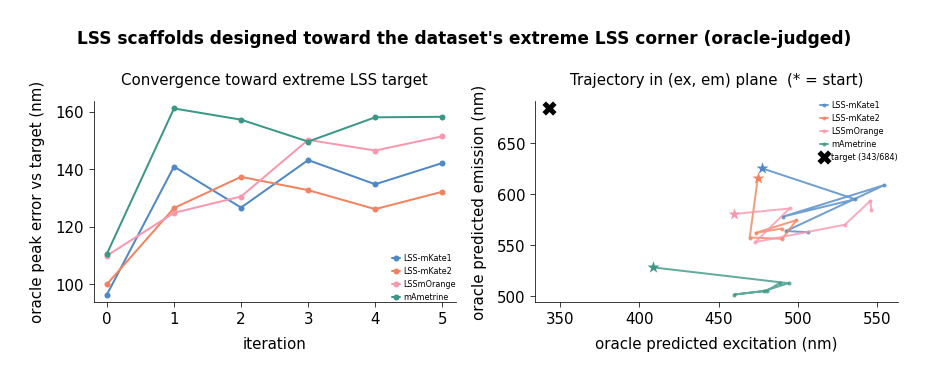

In [9]:
# Actual design: the 4 LSS proteins (excluding OOD mBeRFP) as scaffolds, pushed toward the dataset's
# extreme LSS corner (min excitation, max emission). Surrogate guides; ORACLE (ProstT5) judges.
LSS_SCAFFOLDS = {"LSS-mKate1": "eqFP578", "LSS-mKate2": "eqFP578", "LSSmOrange": "DsRed", "mAmetrine": "avGFP"}
TGT_EX, TGT_EM = float(EXM.min()), float(EMM.max())                    # dataset extremes
TARGET_EXT = torch.tensor([TGT_EX, TGT_EM], device=dev)
LSS_OUTDIR = os.path.join("peak_designs", "structure", "lss_scaffolds_to_extreme_minEx_maxEm")
os.makedirs(LSS_OUTDIR, exist_ok=True)
print(f"extreme target = ex {TGT_EX:.0f} (min, {rows[int(EXM.argmin())]['name']}) / "
      f"em {TGT_EM:.0f} (max, {rows[int(EMM.argmax())]['name']}) nm | Stokes shift {TGT_EM - TGT_EX:.0f} nm\n")

def design_from_scaffold(scaf_name, parent, target, outdir, temperature=5.0):
    scaffold = seqs[_name2idx[scaf_name]]; si = _name2idx[scaf_name]
    torch.manual_seed(SEED); np.random.seed(SEED)
    c1 = chromophore_index(scaffold); p2, p3 = c1 + 1, c1 + 2
    pocket = _struct_pocket(parent, scaffold)                          # parent structure -> LSS numbering
    pos_allowed = {p2: AROMATIC} if POS2_AROMATIC else None
    print(f"[{scaf_name}] exp {EXM[si]:.0f}/{EMM[si]:.0f} -> target {target[0]:.0f}/{target[1]:.0f} | parent {parent} | pocket {len(pocket)}")
    def rec(seq, phase, r, nedit):
        P = oracle_peaks(seq)
        return dict(phase=phase, round=r, nedit=nedit, pred_ex=float(P[0, 0]), pred_em=float(P[0, 1]),
                    peak_err=float(peak_err_vec(P, target)[0]), ppl=pseudo_perplexity(seq)[1],
                    ident=sum(x == y for x, y in zip(seq, scaffold)) / len(scaffold), seq=seq)
    hist = [rec(scaffold, "scaffold", 0, 0)]; cur = scaffold; r = 0
    for lab, steps, n in PHASE_PLAN:
        for _ in range(n):
            r += 1; touched = set()
            for nums, up in steps:
                ed = resolve_positions(nums, up, c1, p2, p3, pocket)
                if not ed: continue
                cur, _ = guided_refine(cur, target, n_sweeps=1, k=K_TOP, lam_ex=LAM_EX, lam_em=LAM_EM, editable=ed,
                                       eval_fn=oracle_peaks, pos_allowed=pos_allowed, temperature=temperature, verbose=False)
                touched.update(ed)
            h = rec(cur, lab, r, len(touched)); hist.append(h)
            print(f"  it{r:>2} oracle err {h['peak_err']:.1f} nm (ex {h['pred_ex']:.0f} em {h['pred_em']:.0f}) | ppl {h['ppl']:.1f} | id {h['ident']:.2f}")
    fn = os.path.join(outdir, f"design_{sanitize(scaf_name)}.csv")
    with open(fn, "w", newline="") as fh:
        w = csv.writer(fh); w.writerow(["scaffold", "parent", "round", "phase", "n_editable", "chromo_pos1",
                                        "target_ex", "target_em", "pred_ex", "pred_em", "peak_err", "ppl",
                                        "ident_to_scaffold", "designed_seq", "scaffold_seq"])
        for h in hist:
            w.writerow([scaf_name, parent, h["round"], h["phase"], h["nedit"], c1 + 1, f"{target[0]:.0f}", f"{target[1]:.0f}",
                        f"{h['pred_ex']:.1f}", f"{h['pred_em']:.1f}", f"{h['peak_err']:.2f}", f"{h['ppl']:.2f}",
                        f"{h['ident']:.3f}", h["seq"], scaffold])
    print(f"  saved -> {fn}")
    return hist

RESULTS_LSS = {}
for _scaf, _parent in LSS_SCAFFOLDS.items():
    RESULTS_LSS[_scaf] = design_from_scaffold(_scaf, _parent, TARGET_EXT, LSS_OUTDIR, temperature=5); print()

print(f"{'scaffold':13}{'start ex/em':>13}{'best ex/em':>12}{'oracle err':>11}{'rnd':>5}{'ident':>7}")
for scaf in LSS_SCAFFOLDS:
    H = RESULTS_LSS[scaf]; si = _name2idx[scaf]; best = min(H, key=lambda h: h["peak_err"])
    print(f"{scaf:13}{EXM[si]:>6.0f}/{EMM[si]:<6.0f}{best['pred_ex']:>5.0f}/{best['pred_em']:<6.0f}{best['peak_err']:>11.1f}{best['round']:>5d}{best['ident']:>7.2f}")
print(f"  target = {TGT_EX:.0f}/{TGT_EM:.0f} nm | (ex,em,err) judged by ORACLE (ProstT5); start ex/em = experimental")

if HAVE_PLT:
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.8))
    pal = [apc_c.aegean, apc_c.amber, apc_c.rose, apc_c.seaweed]
    for c, scaf in zip(pal, LSS_SCAFFOLDS):
        H = RESULTS_LSS[scaf]; rr = [h["round"] for h in H]
        ax[0].plot(rr, [h["peak_err"] for h in H], "o-", color=c, label=scaf)
        ex = [h["pred_ex"] for h in H]; em = [h["pred_em"] for h in H]
        ax[1].plot(ex, em, "o-", color=c, label=scaf, alpha=0.8, ms=4)
        ax[1].scatter([ex[0]], [em[0]], color=c, marker="*", s=160, zorder=5)          # start (oracle pred)
    ax[0].set_xlabel("iteration"); ax[0].set_ylabel("oracle peak error vs target (nm)"); ax[0].set_title("Convergence toward extreme LSS target"); ax[0].legend(fontsize=8)
    ax[1].scatter([TGT_EX], [TGT_EM], marker="X", s=200, color="black", zorder=6, label="target (343/684)")
    ax[1].set_xlabel("oracle predicted excitation (nm)"); ax[1].set_ylabel("oracle predicted emission (nm)")
    ax[1].set_title("Trajectory in (ex, em) plane  (* = start)"); ax[1].legend(fontsize=8)
    fig.suptitle("LSS scaffolds designed toward the dataset's extreme LSS corner (oracle-judged)", fontweight="bold")
    fig.tight_layout(); plt.show()